# 11 - Build CJEU → CJEU Network & First Analysis

This notebook builds a directed homogeneous citation network between CJEU cases,
and performs a focused first analysis using the most interpretable metrics for a same-layer citation network.

**Input:** `data/processed/cjeu_cjeu_case_matches.csv`

**Output:**
- `data/processed/network/cjeu_cjeu_nodes.csv`
- `data/processed/network/cjeu_cjeu_edges.csv`
- `data/processed/network/cjeu_cjeu_network.graphml`
- `data/processed/network/cjeu_cjeu_network.gexf`
- `data/processed/network/cjeu_cjeu_node_metrics.csv`

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/processed")
INPUT_PATH = DATA_DIR / "cjeu_cjeu_case_matches.csv"

OUT_DIR           = DATA_DIR / "network" / "cjeu_cjeu"
NODES_PATH        = OUT_DIR / "cjeu_cjeu_nodes.csv"
EDGES_PATH        = OUT_DIR / "cjeu_cjeu_edges.csv"
GRAPHML_PATH      = OUT_DIR / "cjeu_cjeu_network.graphml"
NODE_METRICS_PATH = OUT_DIR / "cjeu_cjeu_node_metrics.csv"

GEXF_PATH   = OUT_DIR / "cjeu_cjeu_network.gexf"
FIGURES_DIR = Path("outputs/figures/cjeu_cjeu")

# ── Node colour map (by case type) ───────────────────────────────────────────
COLOR_MAP = {
    "c_case": {"hex": "#1f77b4", "rgb": {"r": 31,  "g": 119, "b": 180, "a": 1.0}},
    "t_case": {"hex": "#ff7f0e", "rgb": {"r": 255, "g": 127, "b": 14,  "a": 1.0}},
    "other":  {"hex": "#999999", "rgb": {"r": 153, "g": 153, "b": 153, "a": 1.0}},
}

# ── Single main colour for all ranking bar charts ─────────────────────────────
COLOR_CJEU = "#4C72B0"

# ── Shared matplotlib style ───────────────────────────────────────────────────
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor":"white",
    "text.color":       "black",
    "axes.labelcolor":  "black",
    "xtick.color":      "black",
    "ytick.color":      "black",
    "axes.edgecolor":   "black",
})

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Load CSV

In [2]:
df = pd.read_csv(INPUT_PATH, dtype=str).fillna("")

print(f"Rows loaded : {len(df):,}")
print(f"Columns     : {list(df.columns)}")
df.head(3)

Rows loaded : 8,397
Columns     : ['source_celex_id', 'source_cellar_id', 'source_case_number', 'source_title', 'source_document_date', 'target_celex_id', 'target_cellar_id', 'target_case_number', 'target_title', 'matched_text', 'normalized_match', 'citation_style', 'is_old_case_citation', 'match_context', 'document_source_url', 'document_format', 'processing_status']


,source_celex_id,source_cellar_id,source_case_number,source_title,source_document_date,target_celex_id,target_cellar_id,target_case_number,target_title,matched_text,normalized_match,citation_style,is_old_case_citation,match_context,document_source_url,document_format,processing_status
0,62001CO0481,b9b9c80a-a905-49aa-9d0b-84507e16f7e8,,,2002-04-11,61982CJ0228,dec25a15-43e0-46ef-922e-7d22e5153f43,C-228/82,,228/82,228/82,old_unprefixed,True,"lish Special Edition 1959-1962, p. 87), as int...",https://publications.europa.eu/resource/celex/...,html_eng,matched
1,62001CO0481,b9b9c80a-a905-49aa-9d0b-84507e16f7e8,,,2002-04-11,61972CJ0006,d6fe2a5c-f98a-4395-ad0a-194f70bcd83c,C-6/72,,6/72,6/72,old_unprefixed,True,nd especially to safeguard the interests of co...,https://publications.europa.eu/resource/celex/...,html_eng,matched
2,62001CO0481,b9b9c80a-a905-49aa-9d0b-84507e16f7e8,,,2002-04-11,61984CJ0042,c1357833-ad01-4c62-8124-255678718e3d,C-42/84,,42/84,42/84,old_unprefixed,True,", whether the statement of reasons is adequate...",https://publications.europa.eu/resource/celex/...,html_eng,matched


## 3. Filter: Only Valid Matches

In [3]:
matched = df[df["processing_status"].str.strip() == "matched"].copy()

# Drop rows with missing source or target celex ids
matched = matched[
    matched["source_celex_id"].str.strip().ne("") &
    matched["target_celex_id"].str.strip().ne("")
].copy()

# Remove self-citations
matched = matched[
    matched["source_celex_id"].str.strip() != matched["target_celex_id"].str.strip()
].copy()

print(f"Rows after filtering: {len(matched):,}")
print(f"Unique processing_status values: {matched['processing_status'].unique()}")

Rows after filtering: 8,397
Unique processing_status values: <StringArray>
['matched']
Length: 1, dtype: str


## 4. Deduplicate to One Edge per Source-Target Pair

Each raw row represents one pattern match. Multiple rows may exist for the same
source-target pair. We aggregate them into one unique directed edge per
`(source_celex_id, target_celex_id)` pair, keeping useful aggregated attributes.

In [4]:
edges_raw = (
    matched
    .groupby(["source_celex_id", "target_celex_id"], sort=False)
    .agg(
        source_case_number    = ("source_case_number", "first"),
        target_case_number    = ("target_case_number", "first"),
        match_count           = ("citation_style", "count"),
        citation_styles       = ("citation_style", lambda s: "|".join(s.unique())),
        example_match_context = ("match_context", "first"),
    )
    .reset_index()
)

print(f"Unique CJEU-CJEU pairs (edges): {len(edges_raw):,}")
edges_raw.head(3)

Unique CJEU-CJEU pairs (edges): 8,383


,source_celex_id,target_celex_id,source_case_number,target_case_number,match_count,citation_styles,example_match_context
0,62001CO0481,61982CJ0228,,C-228/82,1,old_unprefixed,"lish Special Edition 1959-1962, p. 87), as int..."
1,62001CO0481,61972CJ0006,,C-6/72,1,old_unprefixed,nd especially to safeguard the interests of co...
2,62001CO0481,61984CJ0042,,C-42/84,1,old_unprefixed,", whether the statement of reasons is adequate..."


## 5. Build Node Table

All CJEU cases that appear as source or target are collected into a single node table.
Source and target metadata are merged carefully so each case appears only once.

In [5]:
# ── Source node metadata ───────────────────────────────────────────────────────
src_meta = (
    matched[["source_celex_id", "source_cellar_id", "source_case_number",
             "source_title", "source_document_date"]]
    .drop_duplicates(subset="source_celex_id")
    .rename(columns={
        "source_celex_id"      : "celex_id",
        "source_cellar_id"     : "cellar_id",
        "source_case_number"   : "case_number",
        "source_title"         : "label",
        "source_document_date" : "date",
    })
    .copy()
)

# ── Target node metadata ───────────────────────────────────────────────────────
tgt_meta = (
    matched[["target_celex_id", "target_cellar_id", "target_case_number", "target_title"]]
    .drop_duplicates(subset="target_celex_id")
    .rename(columns={
        "target_celex_id"    : "celex_id",
        "target_cellar_id"   : "cellar_id",
        "target_case_number" : "case_number",
        "target_title"       : "label",
    })
    .copy()
)
tgt_meta["date"] = ""

# ── Merge: source metadata takes priority ─────────────────────────────────────
all_meta = pd.concat([src_meta, tgt_meta], ignore_index=True)
all_meta = all_meta.drop_duplicates(subset="celex_id", keep="first")

cjeu_nodes = pd.DataFrame({
    "node_id"    : "cjeu:" + all_meta["celex_id"],
    "node_type"  : "cjeu",
    "label"      : all_meta["label"].values,
    "celex_id"   : all_meta["celex_id"].values,
    "cellar_id"  : all_meta["cellar_id"].values,
    "case_number": all_meta["case_number"].values,
    "date"       : all_meta["date"].values,
})

print(f"CJEU nodes: {len(cjeu_nodes):,}")
cjeu_nodes.head(3)

CJEU nodes: 1,997


,node_id,node_type,label,celex_id,cellar_id,case_number,date
0,cjeu:62001CO0481,cjeu,,62001CO0481,b9b9c80a-a905-49aa-9d0b-84507e16f7e8,,2002-04-11
1,cjeu:62000CO0241,cjeu,,62000CO0241,e5c51775-cb8c-4db5-8f62-cd29e5a9e83d,,2001-10-18
2,cjeu:61998CO0428,cjeu,,61998CO0428,bf6d8840-50ac-4342-a168-fc52d1fd33ab,,2000-05-11


## 6. Build Edge Table

In [6]:
edges = edges_raw.copy()
edges.insert(0, "source", "cjeu:" + edges["source_celex_id"])
edges.insert(1, "target", "cjeu:" + edges["target_celex_id"])

print(f"Edges: {len(edges):,}")
edges.head(3)

Edges: 8,383


,source,target,source_celex_id,target_celex_id,source_case_number,target_case_number,match_count,citation_styles,example_match_context
0,cjeu:62001CO0481,cjeu:61982CJ0228,62001CO0481,61982CJ0228,,C-228/82,1,old_unprefixed,"lish Special Edition 1959-1962, p. 87), as int..."
1,cjeu:62001CO0481,cjeu:61972CJ0006,62001CO0481,61972CJ0006,,C-6/72,1,old_unprefixed,nd especially to safeguard the interests of co...
2,cjeu:62001CO0481,cjeu:61984CJ0042,62001CO0481,61984CJ0042,,C-42/84,1,old_unprefixed,", whether the statement of reasons is adequate..."


## 7. Build NetworkX Directed Graph

In [7]:
def classify_case(case_number: str) -> str:
    """Classify a CJEU case number into c_case, t_case, or other."""
    cn = str(case_number).strip()
    if cn.startswith("C-"):
        return "c_case"
    elif cn.startswith("T-"):
        return "t_case"
    else:
        return "other"


G = nx.DiGraph()

for _, row in cjeu_nodes.iterrows():
    ntype = classify_case(row["case_number"])
    G.add_node(
        row["node_id"],
        node_type=ntype,
        node_color=COLOR_MAP[ntype]["hex"],
        label=row["label"],
        celex_id=row["celex_id"],
        cellar_id=row["cellar_id"],
        case_number=row["case_number"],
        date=row["date"],
    )

for _, row in edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        match_count=int(row["match_count"]),
        citation_styles=row["citation_styles"],
        example_match_context=str(row["example_match_context"])[:300],
    )

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph: 1,997 nodes, 8,383 edges


## 8. Basic Statistics

In [8]:
print(f"CJEU nodes : {len(cjeu_nodes):,}")
print(f"Edges      : {len(edges):,}")
print(f"Is directed: {G.is_directed()}")

CJEU nodes : 1,997
Edges      : 8,383
Is directed: True


---
## 9. Citation Style Distribution

A quick look at how many matches come from each citation style (`modern_prefixed` vs `old_unprefixed`).
This is a descriptive note, not a major analysis section.

In [9]:
style_counts = matched["citation_style"].value_counts().reset_index()
style_counts.columns = ["citation_style", "match_count"]

print("Citation style distribution (raw match rows):")
display(style_counts)

Citation style distribution (raw match rows):


,citation_style,match_count
0,old_unprefixed,5725
1,modern_prefixed,2672


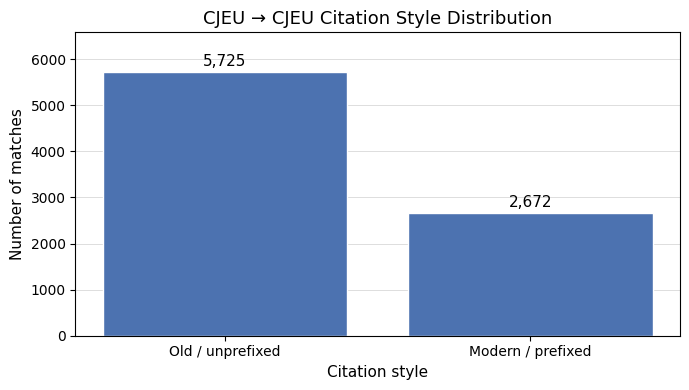

Saved: fig_cjeu_cjeu_citation_style_distribution.png


In [10]:
_sc = matched["citation_style"].value_counts()
_label_map = {
    "old_unprefixed":  "Old / unprefixed",
    "modern_prefixed": "Modern / prefixed",
}
_labels_plot = [_label_map.get(s, s) for s in _sc.index]
_values_plot = _sc.values

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
bars = ax.bar(_labels_plot, _values_plot, color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, _values_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(_values_plot) * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=11, color="black")
ax.set_ylim(0, max(_values_plot) * 1.15)
ax.set_title("CJEU → CJEU Citation Style Distribution", fontsize=13, color="black")
ax.set_ylabel("Number of matches", fontsize=11, color="black")
ax.set_xlabel("Citation style", fontsize=11, color="black")
ax.tick_params(colors="black")
ax.yaxis.grid(True, color="#dddddd", linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_citation_style_distribution.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_citation_style_distribution.png")

---
## 10. Network Structure Metrics

The sections below compute three structural properties of the CJEU → CJEU citation graph:
**reciprocity**, **weakly connected components**, and **strongly connected components**.

### 10.1 Reciprocity

**What it measures:**
Reciprocity is the fraction of edges that are mutual — if case A cites case B, does case B also cite case A?
A value of 0 means no mutual citations; 1 means every citation is reciprocated.

**Why it matters:**
In a legal citation network, high reciprocity would be unusual (decisions typically cite earlier cases).
Low reciprocity confirms the expected temporal, hierarchical structure of case law.

In [11]:
recip = nx.reciprocity(G)
print(f"Network reciprocity: {recip:.4f}")
print(f"({recip*100:.2f}% of edges are mutual citations)")

Network reciprocity: 0.0329
(3.29% of edges are mutual citations)


### 10.2 Weakly Connected Components

**What it measures:**
A weakly connected component (WCC) is a maximal set of nodes reachable from each other
if edge directions are ignored. A large dominant WCC means most CJEU cases are structurally
linked through the citation graph.

**Why it matters:**
WCCs reveal whether the network forms one large connected cluster or splits into isolated sub-networks.
Small isolated components may indicate peripheral citation clusters.

In [12]:
wccs = list(nx.weakly_connected_components(G))
wccs_sorted = sorted(wccs, key=len, reverse=True)

print(f"Number of weakly connected components : {len(wccs_sorted):,}")
print(f"Largest WCC size                       : {len(wccs_sorted[0]):,} nodes")
print(f"Nodes in largest WCC (% of total)      : {len(wccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")

wcc_summary = pd.DataFrame({
    "component_id": range(1, len(wccs_sorted) + 1),
    "size"        : [len(c) for c in wccs_sorted],
})

print("\nWeakly connected component sizes (top 20):")
display(wcc_summary.head(20))

Number of weakly connected components : 27
Largest WCC size                       : 1,940 nodes
Nodes in largest WCC (% of total)      : 97.1%

Weakly connected component sizes (top 20):


,component_id,size
0,1,1940
1,2,4
2,3,4
3,4,3
4,5,2
5,6,2
6,7,2
7,8,2
8,9,2
9,10,2


Largest WCC: 1,940 nodes (shown in title, excluded from bar chart)
Remaining components: 26 (sizes 1–4)


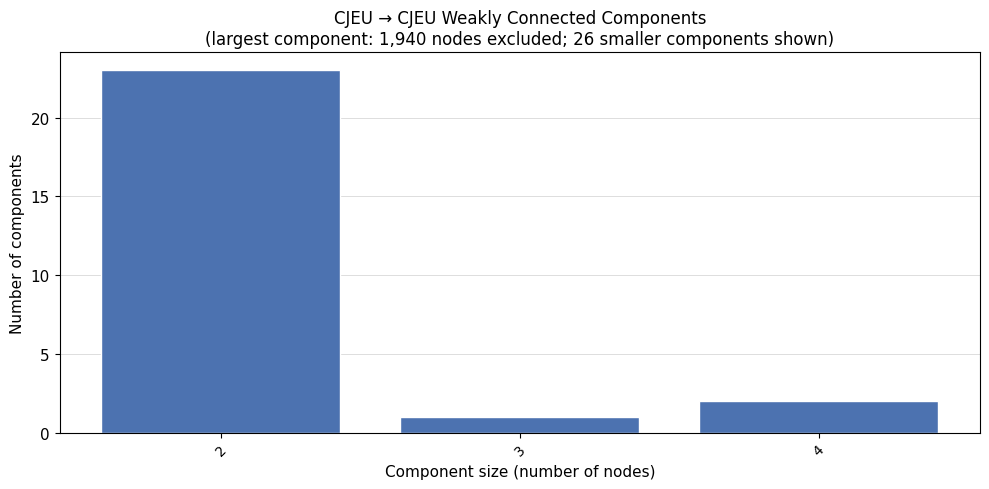

Saved: fig_cjeu_cjeu_wcc_distribution.png


In [13]:
# WCC distribution figure — show only components of size <= 20 to avoid the large component
# dominating the chart; summarise the large component in the title
_wcc_sizes = [len(c) for c in wccs_sorted]
_largest   = _wcc_sizes[0]
_small_sizes = [s for s in _wcc_sizes if s < _largest]

# Count occurrences of each small-component size
_size_counts = pd.Series(_small_sizes).value_counts().sort_index()

print(f"Largest WCC: {_largest:,} nodes (shown in title, excluded from bar chart)")
print(f"Remaining components: {len(_small_sizes):,} (sizes 1–{max(_small_sizes) if _small_sizes else 0})")

if _size_counts.empty:
    print("All nodes are in a single component — no distribution chart needed.")
else:
    fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
    ax.set_facecolor("white")
    ax.bar(_size_counts.index.astype(str), _size_counts.values, color=COLOR_CJEU, edgecolor="white")
    ax.set_title(
        f"CJEU → CJEU Weakly Connected Components\n"
        f"(largest component: {_largest:,} nodes excluded; {len(_small_sizes):,} smaller components shown)",
        fontsize=12, color="black"
    )
    ax.set_xlabel("Component size (number of nodes)", fontsize=11, color="black")
    ax.set_ylabel("Number of components", fontsize=11, color="black")
    ax.tick_params(axis="x", labelrotation=45, labelsize=10, colors="black")
    ax.tick_params(axis="y", labelsize=11, colors="black")
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.7)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_wcc_distribution.png",
                dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
    plt.show()
    print("Saved: fig_cjeu_cjeu_wcc_distribution.png")

### 10.3 Strongly Connected Components

**What it measures:**
A strongly connected component (SCC) is a maximal set of nodes where every node can reach
every other node following directed edges. In a citation network, large SCCs indicate
cycles of mutual citation.

**Why it matters:**
Most legal citation networks are nearly acyclic (older cases cannot cite newer ones),
so most SCCs will be trivial (size 1). A non-trivial SCC indicates mutual or circular citation patterns.

In [14]:
sccs = list(nx.strongly_connected_components(G))
sccs_sorted = sorted(sccs, key=len, reverse=True)

print(f"Number of strongly connected components : {len(sccs_sorted):,}")
print(f"Largest SCC size                         : {len(sccs_sorted[0]):,} nodes")
print(f"Nodes in largest SCC (% of total)        : {len(sccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")
print(f"Non-trivial SCCs (size > 1)              : {sum(1 for c in sccs_sorted if len(c) > 1):,}")

scc_summary = pd.DataFrame({
    "component_id": range(1, len(sccs_sorted) + 1),
    "size"        : [len(c) for c in sccs_sorted],
})

print("\nStrongly connected component sizes (top 20):")
display(scc_summary.head(20))

Number of strongly connected components : 1,945
Largest SCC size                         : 14 nodes
Nodes in largest SCC (% of total)        : 0.7%
Non-trivial SCCs (size > 1)              : 26

Strongly connected component sizes (top 20):


,component_id,size
0,1,14
1,2,8
2,3,3
3,4,3
4,5,3
5,6,3
6,7,3
7,8,3
8,9,3
9,10,3


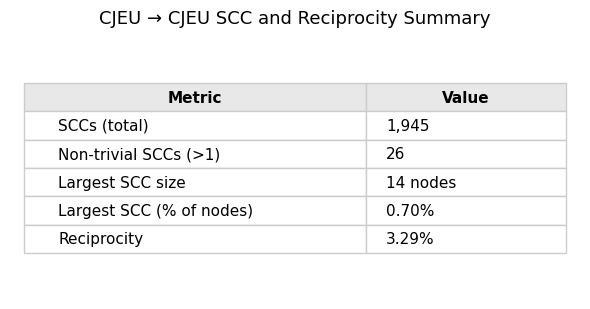

Saved: fig_cjeu_cjeu_scc_reciprocity_summary.png


In [15]:
# SCC & Reciprocity summary — table-style figure (avoids mixed-scale issues)
_num_sccs        = len(sccs_sorted)
_num_nontrivial  = sum(1 for c in sccs_sorted if len(c) > 1)
_largest_scc     = len(sccs_sorted[0])
_scc_share       = _largest_scc / G.number_of_nodes() * 100
_recip_pct       = recip * 100

_rows = [
    ["SCCs (total)",             f"{_num_sccs:,}"],
    ["Non-trivial SCCs (>1)",    f"{_num_nontrivial:,}"],
    ["Largest SCC size",         f"{_largest_scc:,} nodes"],
    ["Largest SCC (% of nodes)", f"{_scc_share:.2f}%"],
    ["Reciprocity",              f"{_recip_pct:.2f}%"],
]

fig, ax = plt.subplots(figsize=(6, 3.2), facecolor="white")
ax.set_facecolor("white")
ax.axis("off")
table = ax.table(
    cellText=_rows,
    colLabels=["Metric", "Value"],
    cellLoc="left",
    loc="center",
    colWidths=[0.6, 0.35],
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if row == 0:
        cell.set_facecolor("#e8e8e8")
        cell.set_text_props(fontweight="bold", color="black")
    else:
        cell.set_facecolor("white")
        cell.set_text_props(color="black")
ax.set_title("CJEU → CJEU SCC and Reciprocity Summary", fontsize=13, color="black", pad=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_scc_reciprocity_summary.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_scc_reciprocity_summary.png")

---
## 11. Visualisation (Top 50 Nodes)

A quick visual impression using the 25 most-cited and 25 most-citing CJEU cases.
Nodes are coloured by role: orange = highly cited, blue = highly citing, green = both.

Subgraph: 50 nodes, 210 edges


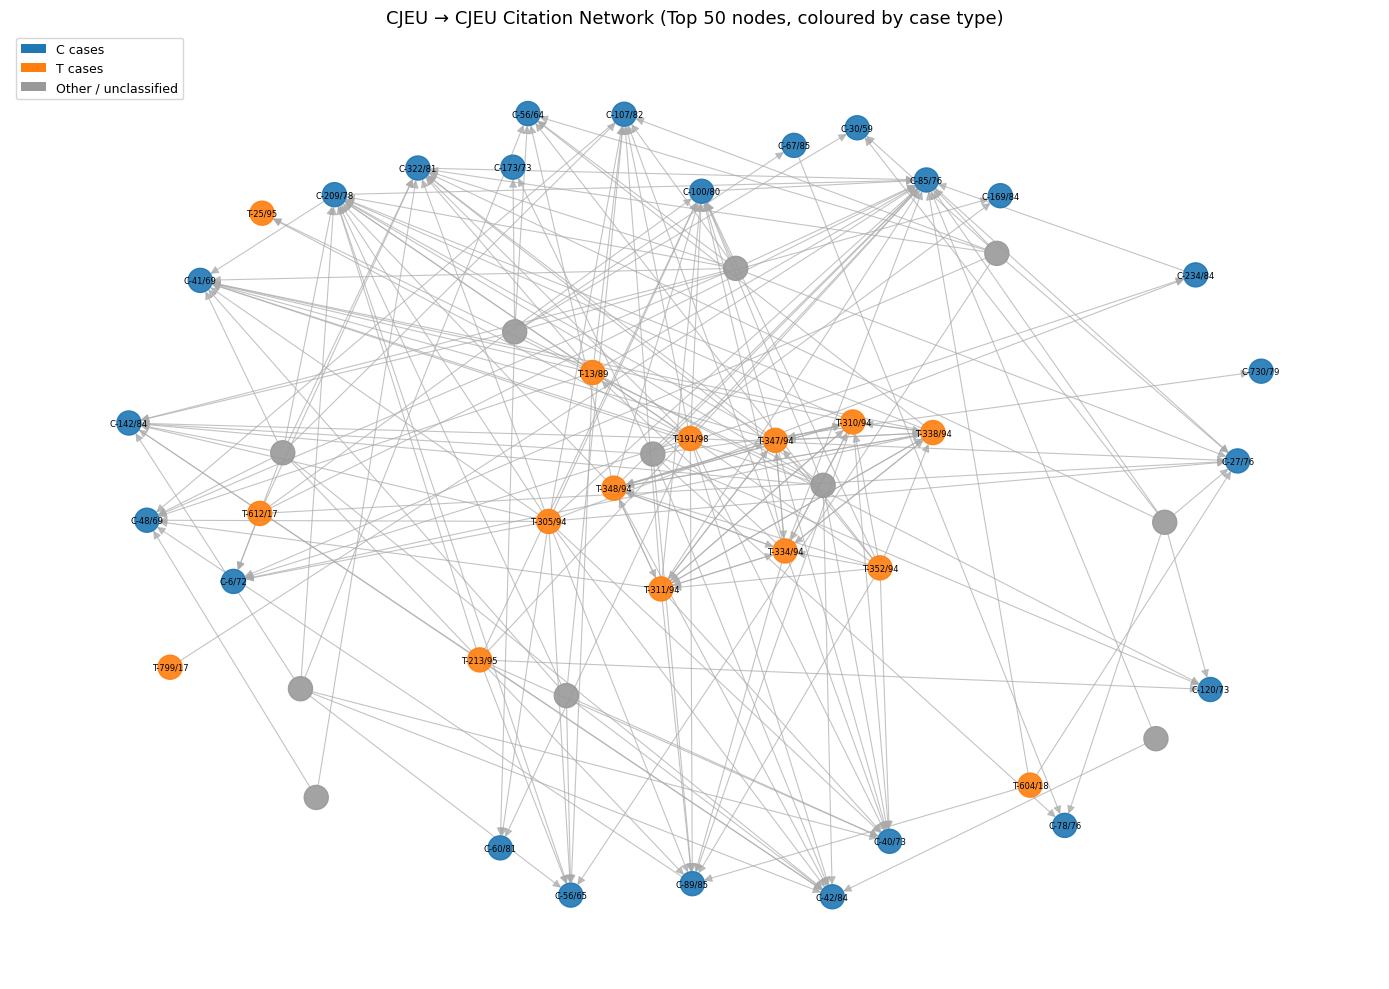

In [16]:
from matplotlib.patches import Patch

in_deg_series  = pd.Series(dict(G.in_degree()),  name="in_degree").sort_values(ascending=False)
out_deg_series = pd.Series(dict(G.out_degree()), name="out_degree").sort_values(ascending=False)

top_cited_ids  = in_deg_series.head(25).index.tolist()
top_citing_ids = out_deg_series.head(25).index.tolist()

sub_nodes = set(top_cited_ids) | set(top_citing_ids)
H = G.subgraph(sub_nodes).copy()

print(f"Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

color_map_vis = [H.nodes[n]["node_color"] for n in H.nodes()]

labels = {n: H.nodes[n].get("case_number", n) for n in H.nodes()}

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=1.5)

nx.draw_networkx_nodes(H, pos, node_color=color_map_vis, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#aaaaaa", arrows=True,
                       arrowsize=12, width=0.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(H, pos, labels=labels, font_size=6, ax=ax)

legend_elements = [
    Patch(facecolor=COLOR_MAP["c_case"]["hex"], label="C cases"),
    Patch(facecolor=COLOR_MAP["t_case"]["hex"], label="T cases"),
    Patch(facecolor=COLOR_MAP["other"]["hex"],  label="Other / unclassified"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("CJEU → CJEU Citation Network (Top 50 nodes, coloured by case type)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 12. Network Analysis

The sections below compute the core node metrics for this directed CJEU citation graph.
Because this is a same-layer network, all standard directed-graph metrics are meaningful:
**in-degree**, **out-degree**, **PageRank**, **HITS**, and **betweenness centrality**.

### 12.1 In-Degree and Out-Degree

**What it measures:**
- **In-degree** = number of incoming edges → how often a CJEU case is *cited by other CJEU cases*.
- **Out-degree** = number of outgoing edges → how many other CJEU cases a document *cites*.

**Why it matters:**
In-degree is the most direct measure of a case's influence within the CJEU corpus.
Out-degree reveals which CJEU documents draw most heavily on prior CJEU precedents.

**Most meaningful for:** both metrics apply equally to all CJEU nodes.

In [17]:
in_degree_all  = dict(G.in_degree())
out_degree_all = dict(G.out_degree())

cjeu_in = (
    cjeu_nodes.set_index("node_id")[["case_number", "label", "date"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
)

print("Top 20 most cited CJEU cases (in-degree):")
display(cjeu_in.head(20))

Top 20 most cited CJEU cases (in-degree):


,case_number,label,date,in_degree
node_id,,,,
cjeu:61980CJ0100,C-100/80,,1983-06-07,185
cjeu:61981CJ0322,C-322/81,,1983-11-09,153
cjeu:61976CJ0085,C-85/76,,1979-02-13,147
cjeu:61973CJ0040,C-40/73,,,137
cjeu:61982CJ0107,C-107/82,,1983-10-25,108
cjeu:61969CJ0041,C-41/69,,,106
cjeu:61979CJ0730,C-730/79,,,102
cjeu:61995TJ0025,T-25/95,,,94
cjeu:61969CJ0048,C-48/69,,,93


In [18]:
cjeu_out = (
    cjeu_nodes.set_index("node_id")[["case_number", "label", "date"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
)

print("Top 20 most citing CJEU cases (out-degree):")
display(cjeu_out.head(20))

Top 20 most citing CJEU cases (out-degree):


,case_number,label,date,out_degree
node_id,,,,
cjeu:61994TJ0305,T-305/94,,1999-04-20,48
cjeu:61996CC0067,,,1999-01-28,46
cjeu:62017TJ0612,T-612/17,,2021-11-10,41
cjeu:61993CC0310,,,1994-12-13,34
cjeu:61993CC0329,,,1996-03-28,33
cjeu:61998TJ0191,T-191/98,,2003-09-30,30
cjeu:61991CC0241,,,1994-06-01,29
cjeu:62017TJ0799,T-799/17,,2022-02-02,28
cjeu:61994TJ0347,T-347/94,,1998-05-14,28


[Consistency] In-Degree Top-10: nodes=10, existing_cn=10, derived_cn=0, celex_fallback=0, nodeid_fallback=0, missing_after=0, plotting=10


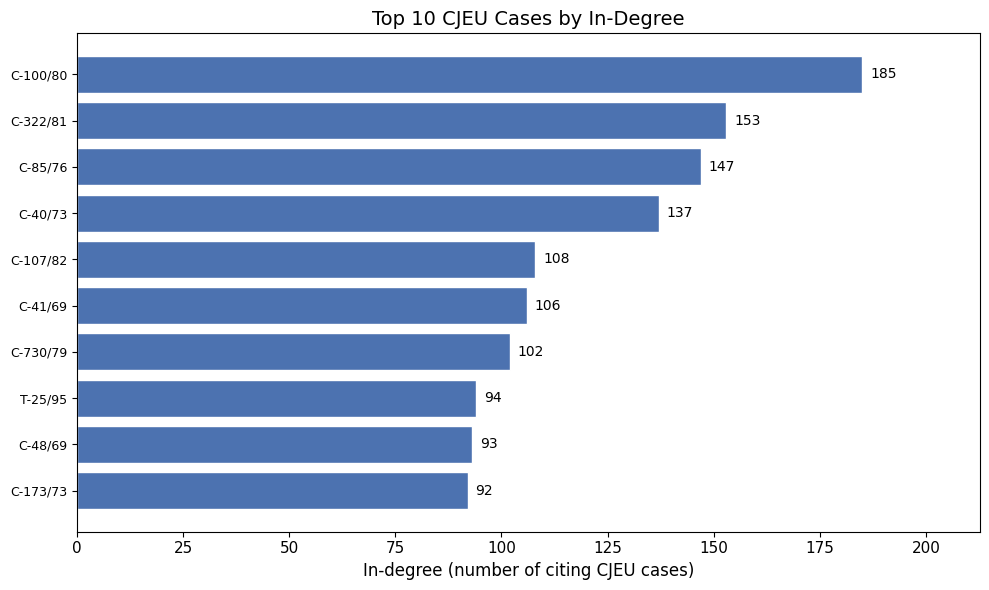

Saved: fig_cjeu_cjeu_top10_indegree.png


In [19]:
# ── Top 10 by In-Degree figure ────────────────────────────────────────────────
# Step 1: rank ALL nodes by metric, then take top 10
_df_indeg = (
    cjeu_nodes.set_index("node_id")[["case_number", "celex_id"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
)
top10_indeg_raw = _df_indeg.head(10).copy()

# Step 2: build fallback label AFTER selecting top 10
import re as _re

def _derive_case_number_from_celex(celex_id: str) -> str:
    """Derive a readable case number from a CELEX ID, e.g. 61973CJ0040 -> C-40/73."""
    m = _re.match(r'^6(\d{4})(CJ|CC|CO|TJ|TC|TO|FJ|FC|FO)(\d+)$', celex_id.strip())
    if not m:
        return ""
    year_str, proc, num_str = m.group(1), m.group(2), m.group(3)
    short_year = year_str[-2:]
    num = int(num_str)
    prefix = "T" if proc in ("TJ","TC","TO") else ("F" if proc in ("FJ","FC","FO") else "C")
    return f"{prefix}-{num}/{short_year}"

def _make_label(row):
    cn = str(row.get("case_number", "")).strip()
    cx = str(row.get("celex_id", "")).strip()
    nid = str(row.name).strip()
    if cn and cn not in ("-", ""):
        return cn
    derived = _derive_case_number_from_celex(cx) if cx else ""
    if derived:
        return derived
    elif cx:
        return cx
    else:
        return nid

# Label source stats will be printed per figure below

top10_indeg_raw["bar_label"] = top10_indeg_raw.apply(_make_label, axis=1)

# Consistency check
_n_existing_cn  = (top10_indeg_raw["case_number"].str.strip().ne("") & top10_indeg_raw["case_number"].str.strip().ne("-")).sum()
_n_derived_cn   = top10_indeg_raw.apply(lambda r: bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_celex_fb     = top10_indeg_raw.apply(lambda r: not bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and bool(str(r.get("celex_id","")).strip()) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_nodeid_fb    = (top10_indeg_raw["bar_label"] == top10_indeg_raw.index.to_series()).sum()
_n_missing_after = (top10_indeg_raw["bar_label"].str.strip().eq("")).sum()
print(f"[Consistency] In-Degree Top-10: nodes={len(top10_indeg_raw)}, existing_cn={_n_existing_cn}, derived_cn={_n_derived_cn}, celex_fallback={_n_celex_fb}, nodeid_fallback={_n_nodeid_fb}, missing_after={_n_missing_after}, plotting={'10' if len(top10_indeg_raw)==10 else str(len(top10_indeg_raw))+' (< 10!)'}")

top10_indeg = top10_indeg_raw.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_indeg["in_degree"].max()
bars = ax.barh(top10_indeg["bar_label"], top10_indeg["in_degree"],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_indeg["in_degree"]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 CJEU Cases by In-Degree", fontsize=14, color="black")
ax.set_xlabel("In-degree (number of citing CJEU cases)", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_top10_indegree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_top10_indegree.png")

[Consistency] Out-Degree Top-10: nodes=10, existing_cn=6, derived_cn=4, celex_fallback=0, nodeid_fallback=0, missing_after=0, plotting=10


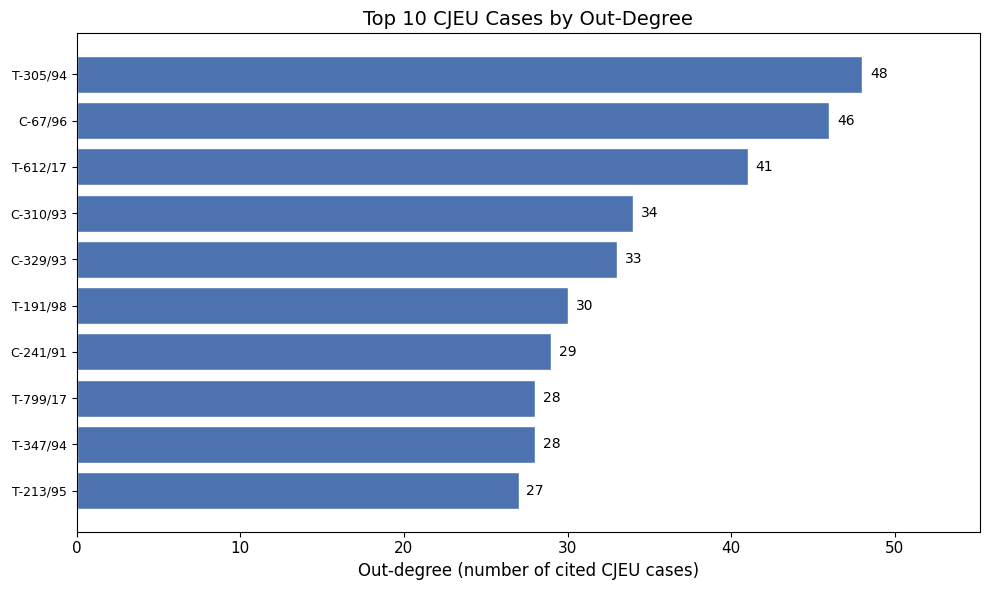

Saved: fig_cjeu_cjeu_top10_outdegree.png


In [20]:
# ── Top 10 by Out-Degree figure ───────────────────────────────────────────────
# Step 1: rank ALL nodes by metric, then take top 10
_df_outdeg = (
    cjeu_nodes.set_index("node_id")[["case_number", "celex_id"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
)
top10_outdeg_raw = _df_outdeg.head(10).copy()
top10_outdeg_raw["bar_label"] = top10_outdeg_raw.apply(_make_label, axis=1)

_n_existing_cn  = (top10_outdeg_raw["case_number"].str.strip().ne("") & top10_outdeg_raw["case_number"].str.strip().ne("-")).sum()
_n_derived_cn   = top10_outdeg_raw.apply(lambda r: bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_celex_fb     = top10_outdeg_raw.apply(lambda r: not bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and bool(str(r.get("celex_id","")).strip()) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_nodeid_fb    = (top10_outdeg_raw["bar_label"] == top10_outdeg_raw.index.to_series()).sum()
_n_missing_after = (top10_outdeg_raw["bar_label"].str.strip().eq("")).sum()
print(f"[Consistency] Out-Degree Top-10: nodes={len(top10_outdeg_raw)}, existing_cn={_n_existing_cn}, derived_cn={_n_derived_cn}, celex_fallback={_n_celex_fb}, nodeid_fallback={_n_nodeid_fb}, missing_after={_n_missing_after}, plotting={'10' if len(top10_outdeg_raw)==10 else str(len(top10_outdeg_raw))+' (< 10!)'}")

top10_outdeg = top10_outdeg_raw.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_outdeg["out_degree"].max()
bars = ax.barh(top10_outdeg["bar_label"], top10_outdeg["out_degree"],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_outdeg["out_degree"]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 CJEU Cases by Out-Degree", fontsize=14, color="black")
ax.set_xlabel("Out-degree (number of cited CJEU cases)", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_top10_outdegree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_top10_outdegree.png")

### 12.2 PageRank

**What it measures:**
PageRank assigns a prestige score to each node based on the number and quality of incoming links.
A node receives a higher score if it is cited by nodes that are themselves highly cited.

**Why it matters:**
Unlike raw in-degree, PageRank accounts for the *importance* of the citing document.
A CJEU case cited by many influential CJEU judgments will rank higher than one cited
by less prominent cases. This identifies the most foundational CJEU precedents.

**Most meaningful for:** all CJEU nodes — identifies the most *prestigious* cases in the network.

In [21]:
pagerank = nx.pagerank(G, alpha=0.85)

cjeu_pr = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values("pagerank", ascending=False)
)

print("Top 20 CJEU cases by PageRank:")
display(cjeu_pr.head(20))

Top 20 CJEU cases by PageRank:


,case_number,label,in_degree,pagerank
node_id,,,,
cjeu:61976CJ0085,C-85/76,,147,0.018375
cjeu:61964CJ0006,C-6/64,,32,0.013186
cjeu:61976CJ0026,C-26/76,,64,0.013017
cjeu:61976CJ0027,C-27/76,,90,0.011224
cjeu:61969CJ0048,C-48/69,,93,0.011175
cjeu:61969CJ0045,C-45/69,,26,0.010017
cjeu:61965CJ0056,C-56/65,,79,0.009708
cjeu:61981CJ0060,C-60/81,,84,0.009675
cjeu:61976CJ0078,C-78/76,,74,0.009539


[Consistency] PageRank Top-10: nodes=10, existing_cn=10, derived_cn=0, celex_fallback=0, nodeid_fallback=0, missing_after=0, plotting=10


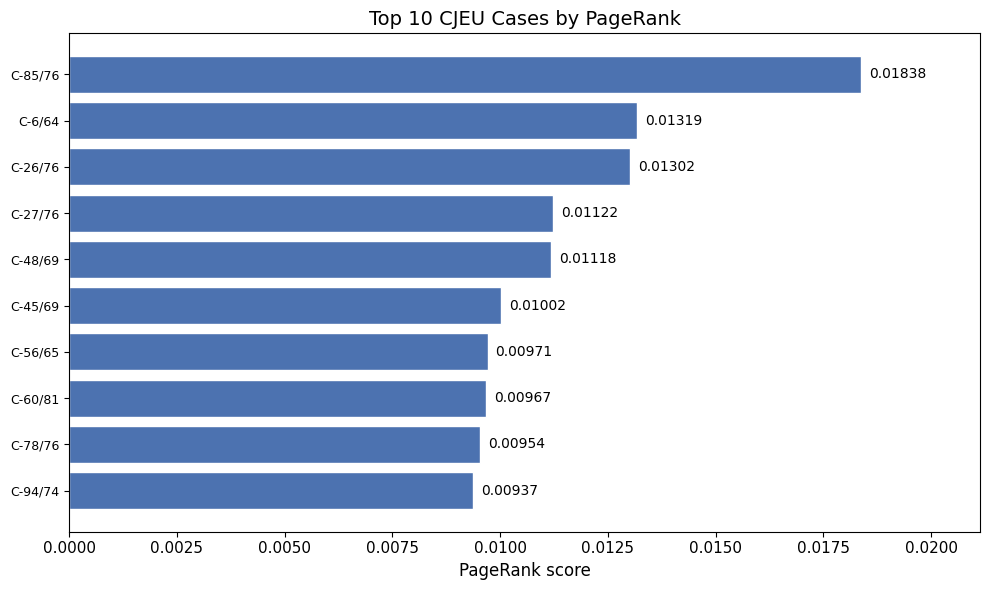

Saved: fig_cjeu_cjeu_top10_pagerank.png


In [22]:
# ── Top 10 by PageRank figure ─────────────────────────────────────────────────
# Step 1: rank ALL nodes by metric, then take top 10
_df_pr = (
    cjeu_nodes.set_index("node_id")[["case_number", "celex_id"]]
    .assign(pagerank=lambda df: df.index.map(pagerank))
    .sort_values("pagerank", ascending=False)
)
top10_pr_raw = _df_pr.head(10).copy()
top10_pr_raw["bar_label"] = top10_pr_raw.apply(_make_label, axis=1)

_n_existing_cn  = (top10_pr_raw["case_number"].str.strip().ne("") & top10_pr_raw["case_number"].str.strip().ne("-")).sum()
_n_derived_cn   = top10_pr_raw.apply(lambda r: bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_celex_fb     = top10_pr_raw.apply(lambda r: not bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and bool(str(r.get("celex_id","")).strip()) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_nodeid_fb    = (top10_pr_raw["bar_label"] == top10_pr_raw.index.to_series()).sum()
_n_missing_after = (top10_pr_raw["bar_label"].str.strip().eq("")).sum()
print(f"[Consistency] PageRank Top-10: nodes={len(top10_pr_raw)}, existing_cn={_n_existing_cn}, derived_cn={_n_derived_cn}, celex_fallback={_n_celex_fb}, nodeid_fallback={_n_nodeid_fb}, missing_after={_n_missing_after}, plotting={'10' if len(top10_pr_raw)==10 else str(len(top10_pr_raw))+' (< 10!)'}")

top10_pr = top10_pr_raw.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_pr["pagerank"].max()
bars = ax.barh(top10_pr["bar_label"], top10_pr["pagerank"],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_pr["pagerank"]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.5f}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 CJEU Cases by PageRank", fontsize=14, color="black")
ax.set_xlabel("PageRank score", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_top10_pagerank.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_top10_pagerank.png")

### 12.3 HITS (Hubs and Authorities)

**What it measures:**
HITS computes two scores per node:
- **Hub score**: how well a node points to good authorities (high out-degree to important cases).
- **Authority score**: how well a node is pointed to by good hubs (cited by important citing cases).

**Why it matters:**
In a CJEU citation network, authority score identifies the most foundational precedents,
while hub score identifies the cases that most systematically reference key precedents.
This complements PageRank by separating the *cited* role from the *citing* role.

**Most meaningful for:** both roles are relevant in a same-layer citation network.

In [23]:
hits_hub, hits_authority = nx.hits(G, max_iter=500)

cjeu_hits_auth = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree =lambda df: df.index.map(in_degree_all),
        authority =lambda df: df.index.map(hits_authority),
        hub       =lambda df: df.index.map(hits_hub),
    )
    .sort_values("authority", ascending=False)
)

print("Top 20 CJEU cases by HITS authority score:")
display(cjeu_hits_auth.head(20))

Top 20 CJEU cases by HITS authority score:


,case_number,label,in_degree,authority,hub
node_id,,,,,
cjeu:61980CJ0100,C-100/80,,185,0.038615,0.000656
cjeu:61973CJ0040,C-40/73,,137,0.032213,-0.000000
cjeu:61981CJ0322,C-322/81,,153,0.031115,0.000546
cjeu:61976CJ0085,C-85/76,,147,0.027375,0.000411
cjeu:61969CJ0041,C-41/69,,106,0.023869,-0.000000
cjeu:61982CJ0107,C-107/82,,108,0.021389,0.000502
cjeu:61995TJ0025,T-25/95,,94,0.019948,-0.000000
cjeu:61969CJ0048,C-48/69,,93,0.019349,-0.000000
cjeu:61978CJ0209,C-209/78,,79,0.018894,0.001237


[Consistency] HITS Authority Top-10: nodes=10, existing_cn=10, derived_cn=0, celex_fallback=0, nodeid_fallback=0, missing_after=0, plotting=10


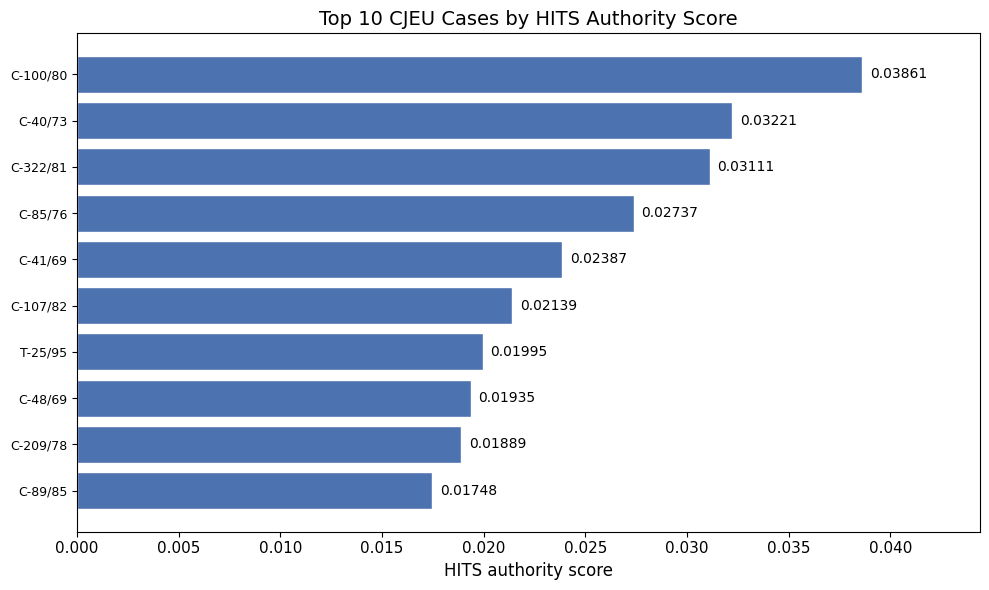

Saved: fig_cjeu_cjeu_top10_hits_authority.png


In [24]:
# ── Top 10 by HITS Authority figure ──────────────────────────────────────────
# Step 1: rank ALL nodes by metric, then take top 10
_df_auth = (
    cjeu_nodes.set_index("node_id")[["case_number", "celex_id"]]
    .assign(authority=lambda df: df.index.map(hits_authority))
    .sort_values("authority", ascending=False)
)
top10_auth_raw = _df_auth.head(10).copy()
top10_auth_raw["bar_label"] = top10_auth_raw.apply(_make_label, axis=1)

_n_existing_cn  = (top10_auth_raw["case_number"].str.strip().ne("") & top10_auth_raw["case_number"].str.strip().ne("-")).sum()
_n_derived_cn   = top10_auth_raw.apply(lambda r: bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_celex_fb     = top10_auth_raw.apply(lambda r: not bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and bool(str(r.get("celex_id","")).strip()) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_nodeid_fb    = (top10_auth_raw["bar_label"] == top10_auth_raw.index.to_series()).sum()
_n_missing_after = (top10_auth_raw["bar_label"].str.strip().eq("")).sum()
print(f"[Consistency] HITS Authority Top-10: nodes={len(top10_auth_raw)}, existing_cn={_n_existing_cn}, derived_cn={_n_derived_cn}, celex_fallback={_n_celex_fb}, nodeid_fallback={_n_nodeid_fb}, missing_after={_n_missing_after}, plotting={'10' if len(top10_auth_raw)==10 else str(len(top10_auth_raw))+' (< 10!)'}")

top10_auth = top10_auth_raw.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_auth["authority"].max()
bars = ax.barh(top10_auth["bar_label"], top10_auth["authority"],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_auth["authority"]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.5f}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 CJEU Cases by HITS Authority Score", fontsize=14, color="black")
ax.set_xlabel("HITS authority score", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_top10_hits_authority.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_top10_hits_authority.png")

### 12.4 Betweenness Centrality

**What it measures:**
Betweenness centrality counts how often a node lies on the shortest path between two other nodes.
A node with high betweenness acts as a *bridge* or *connector* within the network.

**Why it matters:**
In the CJEU citation network, a case with high betweenness is not just frequently cited —
it structurally connects otherwise separate clusters of CJEU decisions.
Such cases may represent pivotal precedents that link different areas of CJEU case law.

**Important note:** Betweenness is a supplementary structural metric.
In-degree and PageRank remain the primary indicators of importance.

In [25]:
betweenness = nx.betweenness_centrality(G, normalized=True)

cjeu_bw = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree   =lambda df: df.index.map(in_degree_all),
        betweenness =lambda df: df.index.map(betweenness),
    )
    .sort_values("betweenness", ascending=False)
)

print("Top 20 CJEU cases by betweenness centrality:")
display(cjeu_bw.head(20))

Top 20 CJEU cases by betweenness centrality:


,case_number,label,in_degree,betweenness
node_id,,,,
cjeu:61989TJ0068,T-68/89,,28,0.001973
cjeu:61981CJ0322,C-322/81,,153,0.001491
cjeu:61980CJ0031,C-31/80,,35,0.001431
cjeu:61998TJ0191,T-191/98,,27,0.001244
cjeu:62000TJ0067,T-67/00,,51,0.001227
cjeu:61989TJ0069,T-69/89,,2,0.001102
cjeu:62002TJ0109,T-109/02,,26,0.000801
cjeu:61994TJ0374,T-374/94,,42,0.000783
cjeu:61992CJ0278,C-278/92,,38,0.000577


[Consistency] Betweenness Top-10: nodes=10, existing_cn=10, derived_cn=0, celex_fallback=0, nodeid_fallback=0, missing_after=0, plotting=10


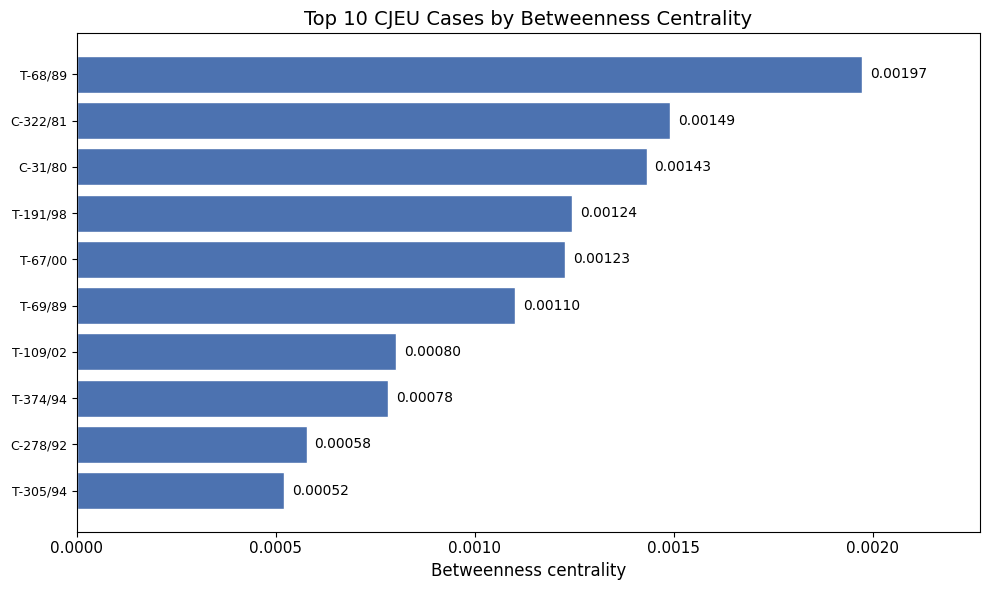

Saved: fig_cjeu_cjeu_top10_betweenness.png


In [26]:
# ── Top 10 by Betweenness figure ──────────────────────────────────────────────
# Step 1: rank ALL nodes by metric, then take top 10
_df_bw = (
    cjeu_nodes.set_index("node_id")[["case_number", "celex_id"]]
    .assign(betweenness=lambda df: df.index.map(betweenness))
    .sort_values("betweenness", ascending=False)
)
top10_bw_raw = _df_bw.head(10).copy()
top10_bw_raw["bar_label"] = top10_bw_raw.apply(_make_label, axis=1)

_n_existing_cn  = (top10_bw_raw["case_number"].str.strip().ne("") & top10_bw_raw["case_number"].str.strip().ne("-")).sum()
_n_derived_cn   = top10_bw_raw.apply(lambda r: bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_celex_fb     = top10_bw_raw.apply(lambda r: not bool(_derive_case_number_from_celex(str(r.get("celex_id","")).strip())) and bool(str(r.get("celex_id","")).strip()) and (str(r.get("case_number","")).strip() in ("","-")), axis=1).sum()
_n_nodeid_fb    = (top10_bw_raw["bar_label"] == top10_bw_raw.index.to_series()).sum()
_n_missing_after = (top10_bw_raw["bar_label"].str.strip().eq("")).sum()
print(f"[Consistency] Betweenness Top-10: nodes={len(top10_bw_raw)}, existing_cn={_n_existing_cn}, derived_cn={_n_derived_cn}, celex_fallback={_n_celex_fb}, nodeid_fallback={_n_nodeid_fb}, missing_after={_n_missing_after}, plotting={'10' if len(top10_bw_raw)==10 else str(len(top10_bw_raw))+' (< 10!)'}")

top10_bw = top10_bw_raw.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")
_max_val = top10_bw["betweenness"].max()
bars = ax.barh(top10_bw["bar_label"], top10_bw["betweenness"],
               color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, top10_bw["betweenness"]):
    ax.text(bar.get_width() + _max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.5f}", va="center", ha="left", fontsize=10, color="black")
ax.set_xlim(0, _max_val * 1.15)
ax.set_title("Top 10 CJEU Cases by Betweenness Centrality", fontsize=14, color="black")
ax.set_xlabel("Betweenness centrality", fontsize=12, color="black")
ax.tick_params(axis="y", labelsize=9, colors="black")
ax.tick_params(axis="x", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_top10_betweenness.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_top10_betweenness.png")

---
## 13. Node-Level Metric Summary Table

All core metrics are combined into a single node-level table for easy inspection and export.
Each row represents one CJEU node with all computed metrics.

In [27]:
node_metrics = cjeu_nodes[["node_id", "label", "case_number", "date"]].copy()

node_metrics["in_degree"]      = node_metrics["node_id"].map(in_degree_all)
node_metrics["out_degree"]     = node_metrics["node_id"].map(out_degree_all)
node_metrics["pagerank"]       = node_metrics["node_id"].map(pagerank)
node_metrics["hits_hub"]       = node_metrics["node_id"].map(hits_hub)
node_metrics["hits_authority"] = node_metrics["node_id"].map(hits_authority)
node_metrics["betweenness"]    = node_metrics["node_id"].map(betweenness)

print(f"Node metrics table: {len(node_metrics):,} rows")
display(node_metrics.sort_values("in_degree", ascending=False).head(20))

Node metrics table: 1,997 rows


,node_id,label,case_number,date,in_degree,out_degree,pagerank,hits_hub,hits_authority,betweenness
734,cjeu:61980CJ0100,,C-100/80,1983-06-07,185,3,0.007423,0.000656,0.038615,0.000188
171,cjeu:61981CJ0322,,C-322/81,1983-11-09,153,2,0.007335,0.000546,0.031115,0.001491
116,cjeu:61976CJ0085,,C-85/76,1979-02-13,147,2,0.018375,0.000411,0.027375,0.000356
1633,cjeu:61973CJ0040,,C-40/73,,137,0,0.005417,-0.000000,0.032213,0.000000
264,cjeu:61982CJ0107,,C-107/82,1983-10-25,108,2,0.005161,0.000502,0.021389,0.000228
1773,cjeu:61969CJ0041,,C-41/69,,106,0,0.004560,-0.000000,0.023869,0.000000
2184,cjeu:61979CJ0730,,C-730/79,,102,0,0.009328,-0.000000,0.001688,0.000000
1667,cjeu:61995TJ0025,,T-25/95,,94,0,0.003423,-0.000000,0.019948,0.000000
1677,cjeu:61969CJ0048,,C-48/69,,93,0,0.011175,-0.000000,0.019349,0.000000
2009,cjeu:61973CJ0173,,C-173/73,,92,0,0.007358,-0.000000,0.001234,0.000000


---
## 13A. Metric Summary Statistics and Distributions

This section provides summary statistics and distribution plots for all node-level metrics
computed in this notebook. Statistics are based on **all CJEU nodes** in the network,
not just the top-10 rankings.

**Metrics covered:**
- `in_degree` — how often each CJEU case is cited by other CJEU cases
- `out_degree` — how many other CJEU cases each document cites
- `pagerank` — prestige-weighted citation score
- `betweenness` — structural bridge score
- `hits_authority` — HITS authority score (cited by good hubs)
- `hits_hub` — HITS hub score (points to good authorities)

In [28]:
from scipy import stats as _scipy_stats

SUMMARY_STATS_PATH = OUT_DIR / "cjeu_cjeu_metric_summary_stats.csv"

def _summary_stats(series: pd.Series, name: str) -> dict:
    """Compute summary statistics for a numeric series."""
    s = series.dropna()
    return {
        "metric"  : name,
        "count"   : int(s.count()),
        "mean"    : round(float(s.mean()), 6),
        "std"     : round(float(s.std()), 6),
        "min"     : round(float(s.min()), 6),
        "25%"     : round(float(s.quantile(0.25)), 6),
        "median"  : round(float(s.median()), 6),
        "75%"     : round(float(s.quantile(0.75)), 6),
        "max"     : round(float(s.max()), 6),
        "skewness": round(float(_scipy_stats.skew(s)), 4),
        "kurtosis": round(float(_scipy_stats.kurtosis(s)), 4),
    }

in_degree_series   = pd.Series({nid: in_degree_all[nid]    for nid in cjeu_nodes["node_id"] if nid in in_degree_all},    name="in_degree")
out_degree_series  = pd.Series({nid: out_degree_all[nid]   for nid in cjeu_nodes["node_id"] if nid in out_degree_all},   name="out_degree")
pagerank_series    = pd.Series({nid: pagerank[nid]          for nid in cjeu_nodes["node_id"] if nid in pagerank},         name="pagerank")
betweenness_series = pd.Series({nid: betweenness[nid]       for nid in cjeu_nodes["node_id"] if nid in betweenness},      name="betweenness")
authority_series   = pd.Series({nid: hits_authority[nid]    for nid in cjeu_nodes["node_id"] if nid in hits_authority},   name="hits_authority")
hub_series         = pd.Series({nid: hits_hub[nid]          for nid in cjeu_nodes["node_id"] if nid in hits_hub},         name="hits_hub")

summary_rows = [
    _summary_stats(in_degree_series,   "in_degree"),
    _summary_stats(out_degree_series,  "out_degree"),
    _summary_stats(pagerank_series,    "pagerank"),
    _summary_stats(betweenness_series, "betweenness"),
    _summary_stats(authority_series,   "hits_authority"),
    _summary_stats(hub_series,         "hits_hub"),
]

summary_stats_df = pd.DataFrame(summary_rows)
print("Metric Summary Statistics — CJEU → CJEU Network")
display(summary_stats_df)

OUT_DIR.mkdir(parents=True, exist_ok=True)
summary_stats_df.to_csv(SUMMARY_STATS_PATH, index=False, encoding="utf-8")
print(f"\nSaved summary stats to: {SUMMARY_STATS_PATH}")

Metric Summary Statistics — CJEU → CJEU Network


,metric,count,mean,std,min,25%,median,75%,max,skewness,kurtosis
0,in_degree,1997,4.197797,13.278444,0.000000,0.000000,0.000000,2.000000,185.000000,6.2447,51.5340
1,out_degree,1997,4.197797,5.194459,0.000000,1.000000,2.000000,6.000000,48.000000,2.4307,9.2012
2,pagerank,1997,0.000501,0.001111,0.000219,0.000219,0.000219,0.000318,0.018375,7.8118,78.4075
3,betweenness,1997,0.000015,0.000093,0.000000,0.000000,0.000000,0.000001,0.001973,12.8058,201.2221
4,hits_authority,1997,0.000501,0.002314,-0.000000,0.000000,0.000000,0.000058,0.038615,8.8526,100.1859
5,hits_hub,1997,0.000501,0.000936,-0.000000,0.000001,0.000067,0.000514,0.007967,2.6688,8.2527



Saved summary stats to: data\processed\network\cjeu_cjeu\cjeu_cjeu_metric_summary_stats.csv


### 13A-1. In-Degree and Out-Degree Distributions

Distribution of in-degree and out-degree across all CJEU nodes. Citation distributions are
typically highly right-skewed; a logarithmic y-axis is used for readability.

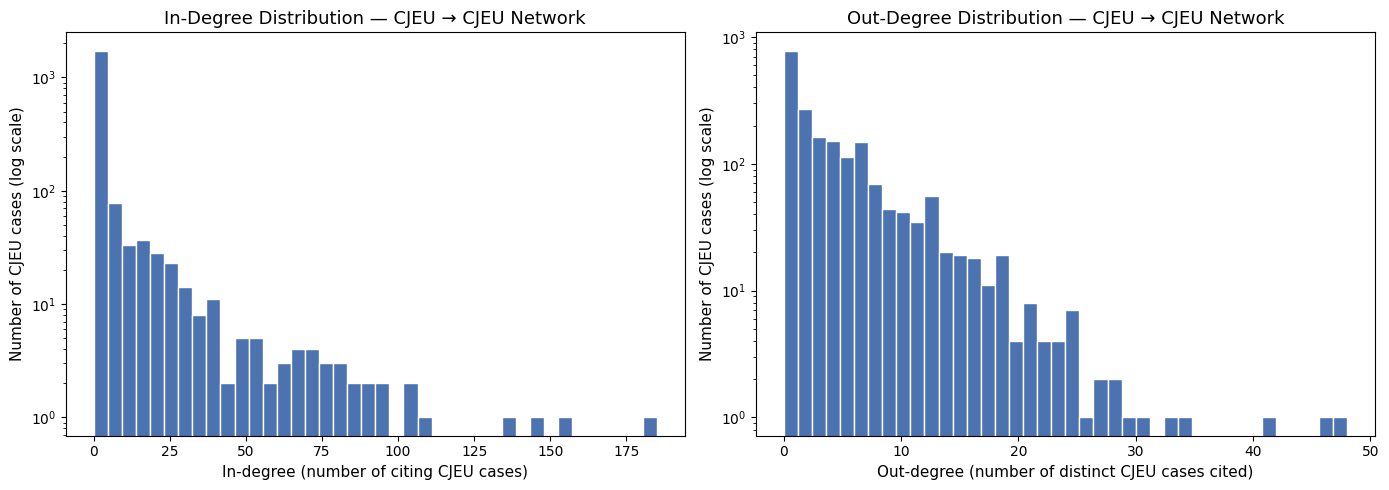

Saved: fig_cjeu_cjeu_dist_degree.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

for ax, series, xlabel, title in [
    (axes[0], in_degree_series,  "In-degree (number of citing CJEU cases)",     "In-Degree Distribution — CJEU → CJEU Network"),
    (axes[1], out_degree_series, "Out-degree (number of distinct CJEU cases cited)", "Out-Degree Distribution — CJEU → CJEU Network"),
]:
    ax.set_facecolor("white")
    ax.hist(series, bins=40, color=COLOR_CJEU, edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13, color="black")
    ax.set_xlabel(xlabel, fontsize=11, color="black")
    ax.set_ylabel("Number of CJEU cases (log scale)", fontsize=11, color="black")
    ax.tick_params(colors="black")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_dist_degree.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_dist_degree.png")

### 13A-2. PageRank Distribution

Distribution of PageRank scores across all CJEU nodes. Extremely right-skewed;
log y-axis used for readability.

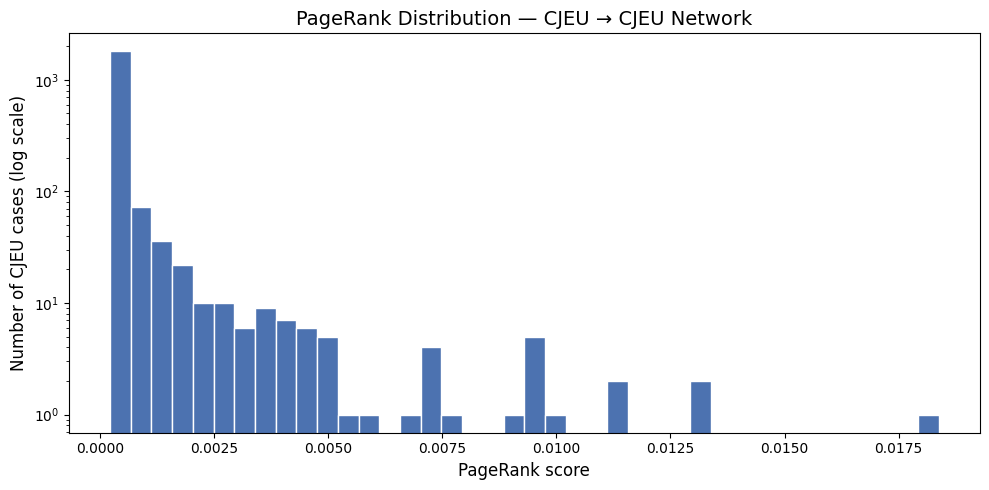

Saved: fig_cjeu_cjeu_dist_pagerank.png


In [30]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
ax.hist(pagerank_series, bins=40, color=COLOR_CJEU, edgecolor="white")
ax.set_yscale("log")
ax.set_title("PageRank Distribution — CJEU → CJEU Network", fontsize=14, color="black")
ax.set_xlabel("PageRank score", fontsize=12, color="black")
ax.set_ylabel("Number of CJEU cases (log scale)", fontsize=12, color="black")
ax.tick_params(colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_dist_pagerank.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_dist_pagerank.png")

### 13A-3. Betweenness Centrality Distribution

Distribution of betweenness centrality across all CJEU nodes. Most nodes have near-zero
betweenness; a small number of bridge nodes have substantially higher values.

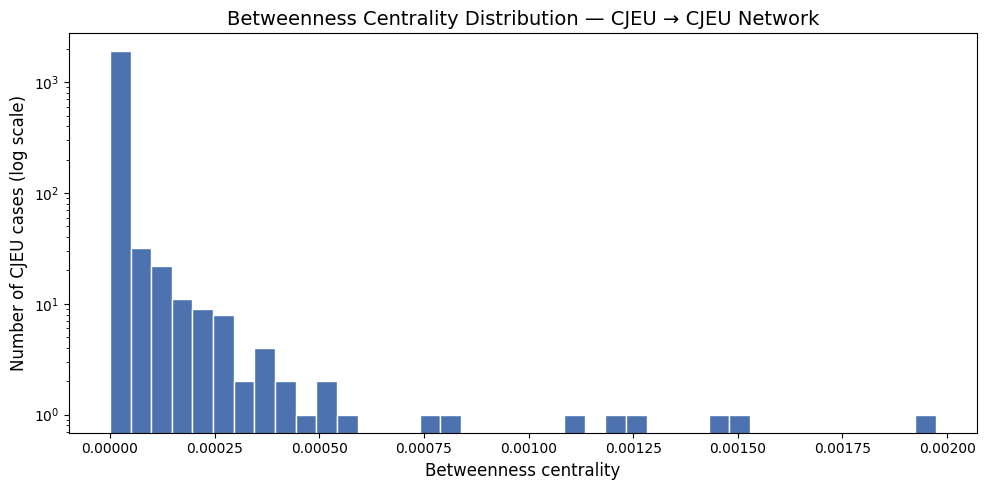

Saved: fig_cjeu_cjeu_dist_betweenness.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
ax.hist(betweenness_series, bins=40, color=COLOR_CJEU, edgecolor="white")
ax.set_yscale("log")
ax.set_title("Betweenness Centrality Distribution — CJEU → CJEU Network", fontsize=14, color="black")
ax.set_xlabel("Betweenness centrality", fontsize=12, color="black")
ax.set_ylabel("Number of CJEU cases (log scale)", fontsize=12, color="black")
ax.tick_params(colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_dist_betweenness.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_dist_betweenness.png")

### 13A-4. HITS Authority and Hub Score Distributions

Distribution of HITS authority and hub scores across all CJEU nodes.
Authority scores identify the most-cited foundational cases; hub scores identify
the cases that most systematically reference key precedents.

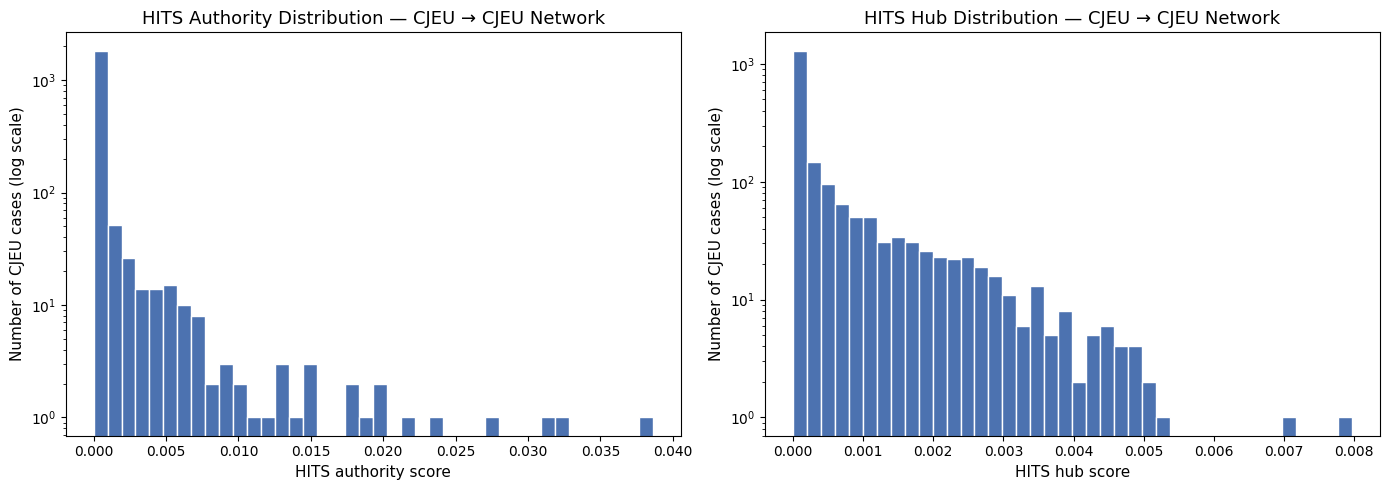

Saved: fig_cjeu_cjeu_dist_hits.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

for ax, series, xlabel, title in [
    (axes[0], authority_series, "HITS authority score", "HITS Authority Distribution — CJEU → CJEU Network"),
    (axes[1], hub_series,       "HITS hub score",       "HITS Hub Distribution — CJEU → CJEU Network"),
]:
    ax.set_facecolor("white")
    ax.hist(series, bins=40, color=COLOR_CJEU, edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13, color="black")
    ax.set_xlabel(xlabel, fontsize=11, color="black")
    ax.set_ylabel("Number of CJEU cases (log scale)", fontsize=11, color="black")
    ax.tick_params(colors="black")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_dist_hits.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_dist_hits.png")

---
## 14. Summary Tables

### 14A. Top Cited CJEU Cases

Ranked by **in-degree** (raw citation count), also showing **PageRank** and **HITS authority**.
These are the CJEU cases most frequently referenced by other CJEU documents.

In [33]:
top_cited = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree =lambda df: df.index.map(in_degree_all),
        pagerank  =lambda df: df.index.map(pagerank),
        authority =lambda df: df.index.map(hits_authority),
    )
    .sort_values(["in_degree", "pagerank"], ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most cited CJEU cases (ranked by in-degree, then PageRank):")
display(top_cited.head(30))

Top 30 most cited CJEU cases (ranked by in-degree, then PageRank):


,case_number,label,in_degree,pagerank,authority
0,C-100/80,,185,0.007423,0.038615
1,C-322/81,,153,0.007335,0.031115
2,C-85/76,,147,0.018375,0.027375
3,C-40/73,,137,0.005417,0.032213
4,C-107/82,,108,0.005161,0.021389
5,C-41/69,,106,0.004560,0.023869
6,C-730/79,,102,0.009328,0.001688
7,T-25/95,,94,0.003423,0.019948
8,C-48/69,,93,0.011175,0.019349
9,C-173/73,,92,0.007358,0.001234


### 14B. Top Citing CJEU Cases

Ranked by **out-degree** (number of distinct CJEU cases cited), also showing **HITS hub score**.
These are the CJEU documents that draw most heavily on prior CJEU precedents.

In [34]:
top_citing = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        out_degree=lambda df: df.index.map(out_degree_all),
        hub       =lambda df: df.index.map(hits_hub),
    )
    .sort_values("out_degree", ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most citing CJEU cases (ranked by out-degree):")
display(top_citing.head(30))

Top 30 most citing CJEU cases (ranked by out-degree):


,case_number,label,out_degree,hub
0,T-305/94,,48,0.007967
1,,,46,0.004253
2,T-612/17,,41,0.003489
3,,,34,0.005092
4,,,33,0.001677
5,T-191/98,,30,0.006975
6,,,29,0.003440
7,T-799/17,,28,0.000676
8,T-347/94,,28,0.004855
9,T-213/95,,27,0.004553


### 14C. Top Bridge Cases by Betweenness

Ranked by **betweenness centrality** — these are the CJEU cases that act as structural bridges
within the citation network, connecting otherwise separate clusters of decisions.

In [35]:
top_bridges = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        betweenness=lambda df: df.index.map(betweenness),
        in_degree  =lambda df: df.index.map(in_degree_all),
        pagerank   =lambda df: df.index.map(pagerank),
    )
    .sort_values("betweenness", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 CJEU bridge cases by betweenness centrality:")
display(top_bridges.head(20))

Top 20 CJEU bridge cases by betweenness centrality:


,case_number,label,betweenness,in_degree,pagerank
0,T-68/89,,0.001973,28,0.001000
1,C-322/81,,0.001491,153,0.007335
2,C-31/80,,0.001431,35,0.004856
3,T-191/98,,0.001244,27,0.001126
4,T-67/00,,0.001227,51,0.002717
5,T-69/89,,0.001102,2,0.000304
6,T-109/02,,0.000801,26,0.001050
7,T-374/94,,0.000783,42,0.001718
8,C-278/92,,0.000577,38,0.003374
9,T-305/94,,0.000521,10,0.000551


---
## 15. Community Detection

Community detection identifies groups of nodes that are more densely connected to each other
than to the rest of the network. In a citation network, communities often correspond to
thematic or procedural clusters — groups of CJEU decisions that frequently cite each other
but cite outside the group less often.

**Modularity** measures how well a partition separates the network into such communities.
A modularity score close to 1 indicates strong community structure; a score near 0 suggests
no more clustering than expected by chance.

**Why this is interesting in same-layer legal citation networks:**
In the CJEU → CJEU network, communities may reflect distinct areas of EU law
(e.g., competition law, fundamental rights, internal market) or different time periods of case law.
This is an exploratory structural metric — it reveals structural groupings in the citation
graph, but does not definitively classify cases by doctrine or legal area.

**Method:** We use the Louvain algorithm built into NetworkX (`nx.community.louvain_communities`),
which is a standard, well-established modularity-based method. Because Louvain requires an
undirected graph, we convert the directed CJEU → CJEU graph to undirected for this step only.
All other metrics above remain computed on the original directed graph.

In [36]:
from networkx.algorithms import community as nx_community

# Convert to undirected for community detection
G_undirected = G.to_undirected()

# Run Louvain community detection
louvain_sets = nx_community.louvain_communities(G_undirected, seed=42)

# Build node → community id mapping
partition = {}
for comm_id, members in enumerate(louvain_sets):
    for node in members:
        partition[node] = comm_id

# Compute modularity
modularity_score = nx_community.modularity(G_undirected, louvain_sets)

num_communities = len(louvain_sets)
print(f"Number of communities detected : {num_communities}")
print(f"Modularity score               : {modularity_score:.4f}")

Number of communities detected : 45
Modularity score               : 0.5456


### 15.1 Community Summary

In [37]:
community_sizes = pd.Series(partition).value_counts().sort_index()
community_summary = pd.DataFrame({
    "community_id": community_sizes.index,
    "num_nodes"   : community_sizes.values,
}).sort_values("num_nodes", ascending=False).reset_index(drop=True)

print("Community sizes (largest first):")
display(community_summary)

print(f"\nLargest community : {community_summary['num_nodes'].iloc[0]:,} nodes")
print(f"Smallest community: {community_summary['num_nodes'].iloc[-1]:,} nodes")

Community sizes (largest first):


,community_id,num_nodes
0,18,620
1,2,381
2,0,303
3,11,231
4,5,119
5,28,65
6,1,53
7,15,43
8,6,34
9,20,30



Largest community : 620 nodes
Smallest community: 2 nodes


### 15.2 Community-Level Interpretation Table

For each community: number of nodes, average in-degree, average PageRank,
and a few example case numbers.

In [38]:
community_details = []
for comm_id, size in community_summary[["community_id", "num_nodes"]].values:
    members = [n for n, c in partition.items() if c == comm_id]
    avg_indeg = sum(in_degree_all.get(n, 0) for n in members) / len(members)
    avg_pr    = sum(pagerank.get(n, 0) for n in members) / len(members)
    examples  = ", ".join(
        G.nodes[n].get("case_number", n)
        for n in sorted(members, key=lambda n: in_degree_all.get(n, 0), reverse=True)[:3]
    )
    community_details.append({
        "community_id"   : int(comm_id),
        "num_nodes"      : int(size),
        "avg_in_degree"  : round(avg_indeg, 2),
        "avg_pagerank"   : round(avg_pr, 6),
        "top_3_examples" : examples,
    })

community_details_df = pd.DataFrame(community_details).sort_values("num_nodes", ascending=False).reset_index(drop=True)
print("Community-level summary (sorted by size):")
display(community_details_df)

Community-level summary (sorted by size):


,community_id,num_nodes,avg_in_degree,avg_pagerank,top_3_examples
0,18,620,3.52,0.000529,"C-730/79, C-173/73, C-78/76"
1,2,381,5.82,0.000523,"C-100/80, C-322/81, C-85/76"
2,0,303,5.30,0.000599,"C-56/64, C-209/78, C-56/65"
3,11,231,3.63,0.000425,"C-66/86, C-127/73, C-13/77"
4,5,119,3.39,0.000462,"C-60/81, C-374/87, C-53/85"
5,28,65,5.58,0.000603,"T-79/89, C-243/83, C-172/80"
6,1,53,3.55,0.000385,"C-238/87, C-78/70, C-262/81"
7,15,43,1.58,0.000350,"C-226/87, C-96/75, C-17/99"
8,6,34,10.59,0.000519,"T-337/94, T-311/94, T-304/94"
9,20,30,2.03,0.000348,"C-17/74, T-310/01, C-51/69"


### 15.3 Add Community to Node Metrics

In [39]:
node_metrics["community"] = node_metrics["node_id"].map(partition)

print("Node metrics table now includes community assignment:")
display(node_metrics.sort_values("in_degree", ascending=False).head(20))

Node metrics table now includes community assignment:


,node_id,label,case_number,date,in_degree,out_degree,pagerank,hits_hub,hits_authority,betweenness,community
734,cjeu:61980CJ0100,,C-100/80,1983-06-07,185,3,0.007423,0.000656,0.038615,0.000188,2
171,cjeu:61981CJ0322,,C-322/81,1983-11-09,153,2,0.007335,0.000546,0.031115,0.001491,2
116,cjeu:61976CJ0085,,C-85/76,1979-02-13,147,2,0.018375,0.000411,0.027375,0.000356,2
1633,cjeu:61973CJ0040,,C-40/73,,137,0,0.005417,-0.000000,0.032213,0.000000,2
264,cjeu:61982CJ0107,,C-107/82,1983-10-25,108,2,0.005161,0.000502,0.021389,0.000228,2
1773,cjeu:61969CJ0041,,C-41/69,,106,0,0.004560,-0.000000,0.023869,0.000000,2
2184,cjeu:61979CJ0730,,C-730/79,,102,0,0.009328,-0.000000,0.001688,0.000000,18
1667,cjeu:61995TJ0025,,T-25/95,,94,0,0.003423,-0.000000,0.019948,0.000000,2
1677,cjeu:61969CJ0048,,C-48/69,,93,0,0.011175,-0.000000,0.019349,0.000000,2
2009,cjeu:61973CJ0173,,C-173/73,,92,0,0.007358,-0.000000,0.001234,0.000000,18


### 15.4 Community Size Distribution

Number of communities detected : 45
Modularity score               : 0.5456
Largest community size         : 620 nodes
Top 5 community sizes          : [np.int64(620), np.int64(381), np.int64(303), np.int64(231), np.int64(119)]


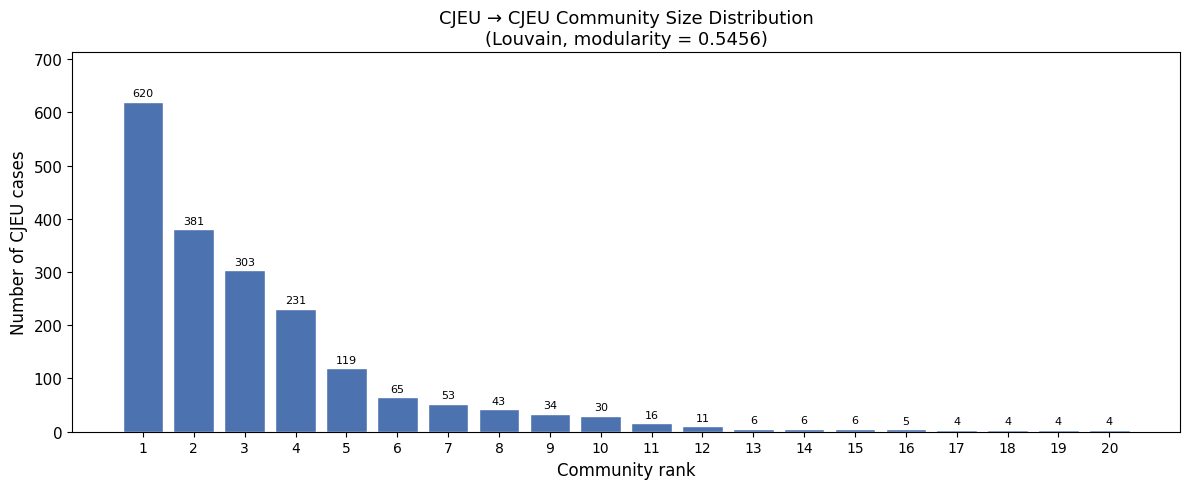

Saved: fig_cjeu_cjeu_community_size_distribution.png


In [40]:
comm_sizes_sorted = community_summary["num_nodes"].values

print(f"Number of communities detected : {num_communities:,}")
print(f"Modularity score               : {modularity_score:.4f}")
print(f"Largest community size         : {comm_sizes_sorted[0]:,} nodes")
print(f"Top 5 community sizes          : {list(comm_sizes_sorted[:5])}")

_top_n = min(20, len(comm_sizes_sorted))
_top_sizes = comm_sizes_sorted[:_top_n]
_top_labels = [str(i + 1) for i in range(_top_n)]

fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
ax.set_facecolor("white")
bars = ax.bar(_top_labels, _top_sizes, color=COLOR_CJEU, edgecolor="white")
for bar, val in zip(bars, _top_sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(_top_sizes) * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=8, color="black")
ax.set_ylim(0, max(_top_sizes) * 1.15)
_subtitle = f" (largest {_top_n} shown)" if len(comm_sizes_sorted) > _top_n else ""
ax.set_title(
    f"CJEU → CJEU Community Size Distribution\n"
    f"(Louvain, modularity = {modularity_score:.4f})",
    fontsize=13, color="black"
)
ax.set_xlabel("Community rank", fontsize=12, color="black")
ax.set_ylabel("Number of CJEU cases", fontsize=12, color="black")
ax.tick_params(axis="x", labelsize=10, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_cjeu_cjeu_community_size_distribution.png",
            dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print("Saved: fig_cjeu_cjeu_community_size_distribution.png")

### 15.5 Visualisation with Community Colours

The same top-50 subgraph as in section 11, but now nodes are coloured by community.

C:\Users\flohe\AppData\Local\Temp\ipykernel_42256\189239411.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(comm_ids))


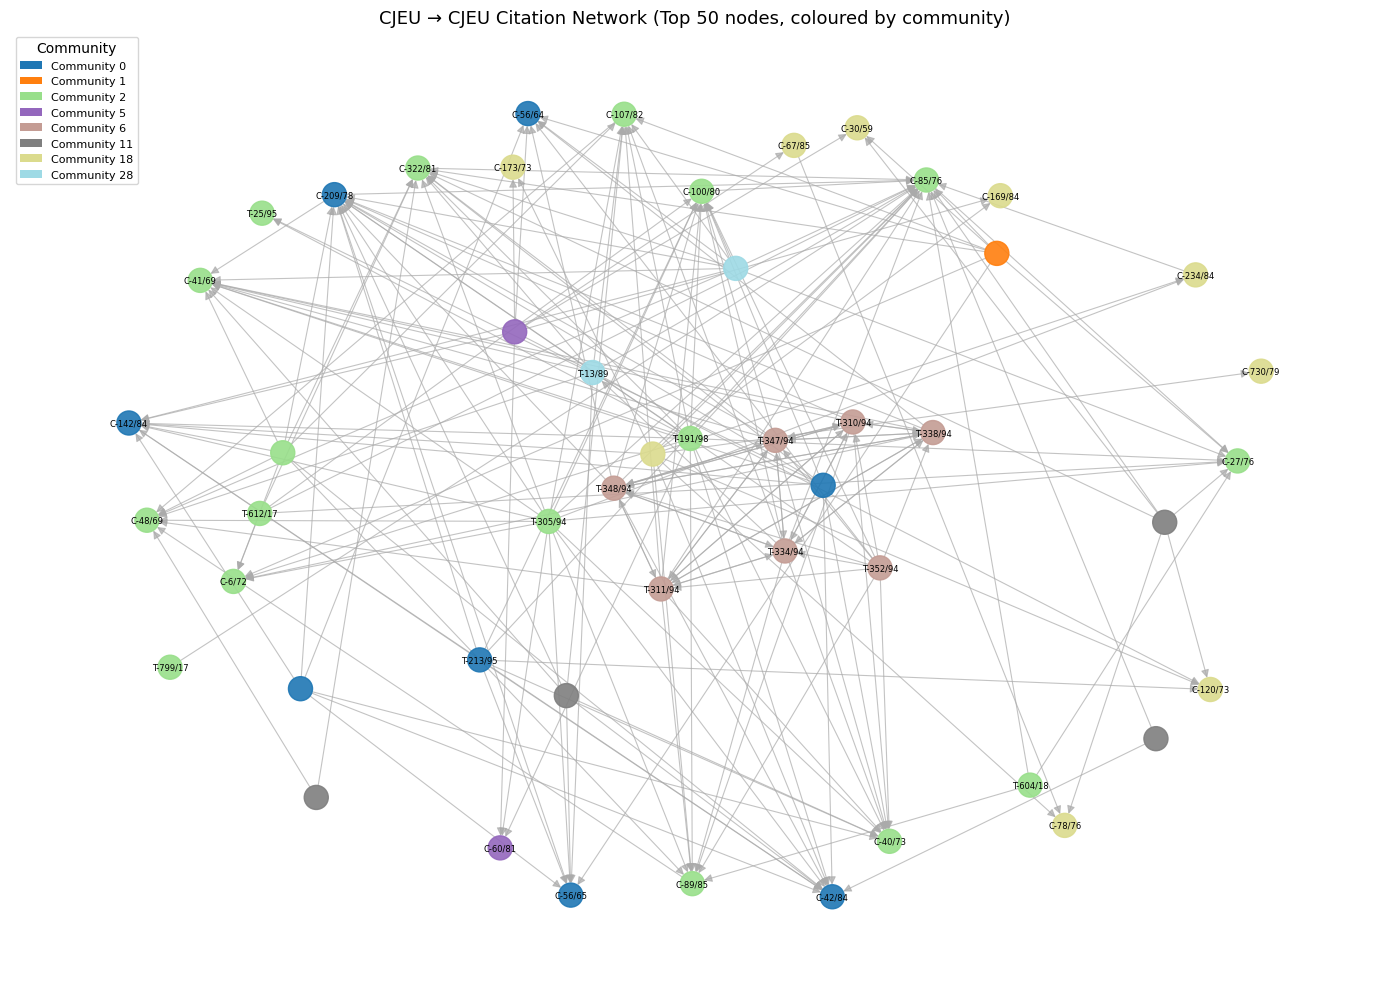

In [41]:
import matplotlib.cm as cm

# Reuse the same subgraph H from section 11
comm_ids = sorted(set(partition.get(n, -1) for n in H.nodes()))
cmap = cm.get_cmap("tab20", len(comm_ids))
comm_color_map = {c: cmap(i) for i, c in enumerate(comm_ids)}

node_colors_comm = [comm_color_map[partition.get(n, -1)] for n in H.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(H, pos, node_color=node_colors_comm, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#aaaaaa", arrows=True,
                       arrowsize=12, width=0.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(H, pos, labels=labels, font_size=6, ax=ax)

legend_patches = [
    Patch(facecolor=comm_color_map[c], label=f"Community {c}")
    for c in comm_ids
]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8, title="Community")
ax.set_title("CJEU → CJEU Citation Network (Top 50 nodes, coloured by community)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 16. Export

In [42]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

cjeu_nodes.to_csv(NODES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(cjeu_nodes):,} nodes to: {NODES_PATH}")

edges.to_csv(EDGES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(edges):,} edges to: {EDGES_PATH}")

nx.write_graphml(G, str(GRAPHML_PATH))
print(f"Saved GraphML to: {GRAPHML_PATH}")

# GEXF with Gephi-compatible viz colours
for node in G.nodes():
    ntype = G.nodes[node].get("node_type", "other")
    rgb   = COLOR_MAP.get(ntype, COLOR_MAP["other"])["rgb"]
    G.nodes[node]["viz"] = {"color": rgb}
nx.write_gexf(G, str(GEXF_PATH))
print(f"Saved GEXF  to: {GEXF_PATH}")

# Node metrics (includes community column)
node_metrics.to_csv(NODE_METRICS_PATH, index=False, encoding="utf-8")
print(f"Saved node metrics to: {NODE_METRICS_PATH}")


Saved 1,997 nodes to: data\processed\network\cjeu_cjeu\cjeu_cjeu_nodes.csv
Saved 8,383 edges to: data\processed\network\cjeu_cjeu\cjeu_cjeu_edges.csv
Saved GraphML to: data\processed\network\cjeu_cjeu\cjeu_cjeu_network.graphml
Saved GEXF  to: data\processed\network\cjeu_cjeu\cjeu_cjeu_network.gexf
Saved node metrics to: data\processed\network\cjeu_cjeu\cjeu_cjeu_node_metrics.csv
